# Notebook 12 — Option 2: BCE Pseudo-label Loss + Reconstruction-only Scoring

## Why previous experiments failed

| Flaw | Effect | Fix |
|---|---|---|
| Score = 0.5×Mahal + 0.5×recon | Mahal identical for ALL activations → floor effect | **Recon-only score** |
| Margin loss goes dead when gap > M | Gradient = 0, stops learning | **BCE: gradient always nonzero** |
| Easy datasets (AUROC=1.0 everywhere) | No discriminative signal | **Hard/structured datasets only** |

## Why BCE beats margin loss

```
Margin:  L = max(0, M − (score_out − score_in))  # gradient=0 when gap satisfied
BCE:     L = −y·log(σ(score)) − (1−y)·log(1−σ(score))  # gradient ALWAYS nonzero
```

**Pseudo-labels (no annotations needed):**  
`y=1` if `recon_err[i] > 85th percentile` (pseudo-outlier)  
`y=0` otherwise (pseudo-inlier)

## Pre-validation (8 seeds, numpy)  

| Dataset | MELU-Δt | Swish | ELU | Winner | Δ(MELU-Swish) |
|---|---|---|---|---|---|
| BreastCancer | 0.9492 | 0.9454 | 0.9505 | ELU | +0.0039 |
| D1v7 | **0.9991** | 0.9918 | 0.9970 | MELU | +0.0073 |
| D3v5 | **0.9896** | 0.9748 | 0.9807 | MELU | +0.0148 |
| D3v8 | **0.9768** | 0.9036 | 0.9384 | MELU | +0.0732 |

MELU wins 3/4 hard datasets with avg **+0.025** advantage.

## Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import betainc, gammaln
from scipy.stats import wilcoxon, friedmanchisquare, rankdata
from sklearn.datasets import load_digits, load_breast_cancer, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings; warnings.filterwarnings("ignore")
np.random.seed(42)

try:
    import torch, torch.nn as nn, torch.optim as optim
    import torch.nn.functional as F
    TORCH=True; torch.manual_seed(42)
    print(f"PyTorch {torch.__version__} — autograd α,β,ν ✓")
except ImportError:
    TORCH=False
    print("numpy mode — α=0.90 β=0.45 ν=4.76 (fixed from nb10)")

ACTS  =["MELU-Δt","Swish","GELU","ELU","ReLU"]
COLORS={"MELU-Δt":"#1D9E75","Swish":"#534AB7","GELU":"#BA7517","ELU":"#888780","ReLU":"#D85A30"}
print("\nScore: recon_err = ||x - x_hat||_1   (NO Mahalanobis in score)")
print("Loss:  MAE + lambda * BCE(pseudo_labels)")


PyTorch 2.5.1+cu121 — autograd α,β,ν ✓

Score: recon_err = ||x - x_hat||_1   (NO Mahalanobis in score)
Loss:  MAE + lambda * BCE(pseudo_labels)


## Cell 2 — Model (PyTorch if available, numpy fallback)

In [2]:
def fast_mcd(Z,hf=0.75,ns=6,nc=5):
    n,d=Z.shape; h=max(int(n*hf),d+1); bd=np.inf; bm=bc=None
    for _ in range(ns):
        idx=np.random.choice(n,h,replace=False); sub=Z[idx]
        for _ in range(nc):
            mu=sub.mean(0); dv=sub-mu
            cov=dv.T@dv/max(len(sub)-1,1)+1e-4*np.eye(d)
            Si=np.linalg.inv(cov)
            ds=np.sqrt(np.maximum(np.einsum('bi,ij,bj->b',Z-mu,Si,Z-mu),0))
            idx=np.argsort(ds)[:h]; sub=Z[idx]
        mu=sub.mean(0); dv=sub-mu; cov=dv.T@dv/max(len(sub)-1,1)
        det=np.linalg.det(cov+1e-4*np.eye(d))
        if det<bd: bd=det; bm=mu; bc=cov
    try:
        L=np.linalg.cholesky(bc+1e-4*np.eye(d)); Li=np.linalg.inv(L)
        if np.isnan(Li).any() or np.linalg.cond(Li)>1e7: Li=np.eye(d)
    except: Li=np.eye(d)
    return bm,bc,Li

# numpy activations
def _sw(x):   return x/(1+np.exp(-np.clip(x,-50,50)))
def _gelu(x): return x*0.5*(1+np.tanh(np.sqrt(2/np.pi)*(x+0.044715*x**3)))
def _elu(x):  return np.where(x>0, x, np.exp(np.clip(x,-20,0))-1)
def _relu(x): return np.maximum(0,x)
def _tcdf(x,nu=5.0):
    z=nu/(nu+np.clip(x**2,1e-30,None))
    ib=betainc(nu/2,0.5,np.clip(z,1e-12,1-1e-12))
    return np.where(x>=0,1.0-ib/2.0,ib/2.0)

def _melu_np(H,mu,Li,tau,alpha=0.90,beta=0.45,nu=4.76):
    T1=H*_tcdf(H,nu)
    if mu.shape[0]!=H.shape[1]: return T1
    w=(H-mu)@Li.T; m=np.sqrt(np.maximum((w**2).sum(1),0))
    gate=(m>=tau).astype(float)[:,None]
    amp=alpha*np.sign(H)*np.tanh(np.clip(beta*(m[:,None]-tau),-8,8))
    return T1+gate*amp

if TORCH:
    class TCDF(torch.autograd.Function):
        @staticmethod
        def forward(ctx,x,lnm2):
            nu=float(2.0+lnm2.exp().item()); xn=x.detach().cpu().numpy()
            z=nu/(nu+np.clip(xn**2,1e-30,None))
            ib=betainc(nu/2,0.5,np.clip(z,1e-12,1-1e-12))
            ctx.save_for_backward(x,lnm2)
            return torch.tensor(np.where(xn>=0,1.0-ib/2.0,ib/2.0),dtype=x.dtype,device=x.device)
        @staticmethod
        def backward(ctx,g):
            x,lnm2=ctx.saved_tensors; nu=float(2.0+lnm2.exp().item())
            xn=x.detach().cpu().numpy()
            lc=gammaln((nu+1)/2)-gammaln(nu/2)-0.5*np.log(nu*np.pi)
            pdf=np.exp(lc-(nu+1)/2*np.log(1+xn**2/nu))
            gx=g*torch.tensor(pdf,dtype=x.dtype,device=x.device)
            eps=0.05
            def cdf_(v):
                z=v/(v+np.clip(xn**2,1e-30,None))
                ib=betainc(v/2,0.5,np.clip(z,1e-12,1-1e-12))
                return np.where(xn>=0,1.0-ib/2.0,ib/2.0)
            dc=(cdf_(nu+eps)-cdf_(nu-eps))/(2*eps)
            gn=(g*torch.tensor(dc,dtype=x.dtype,device=x.device)*float(lnm2.exp())).sum()
            return gx,gn

    class MELUDt(nn.Module):
        def __init__(self):
            super().__init__()
            self.la=nn.Parameter(torch.log(torch.tensor(1.0)))
            self.lb=nn.Parameter(torch.log(torch.tensor(0.5)))
            self.ln=nn.Parameter(torch.log(torch.tensor(3.0)))
            self.register_buffer('mu',torch.zeros(1))
            self.register_buffer('Li',torch.eye(1))
            self.register_buffer('tau',torch.tensor(1.5))
            self.on=False
        @property
        def alpha(self): return self.la.exp()
        @property
        def beta(self):  return self.lb.exp()
        @property
        def nu(self):    return 2.0+self.ln.exp()
        def set_mcd(self,mu,Li,tau):
            d=self.la.device
            self.mu=torch.tensor(mu,dtype=torch.float32,device=d)
            self.Li=torch.tensor(Li,dtype=torch.float32,device=d)
            self.tau=torch.tensor(float(tau),device=d)
        def forward(self,H,x=None):
            T1=H*TCDF.apply(H,self.ln)
            if not self.on or x is None: return T1
            if self.mu.shape[0]!=x.shape[1]: m=x.norm(dim=1)
            else:
                w=(x-self.mu.unsqueeze(0))@self.Li.T; m=w.norm(dim=1)
            g=(m>=self.tau).float().unsqueeze(1)
            a=self.alpha*H.sign()*torch.tanh(self.beta*(m-self.tau).clamp(-8,8).unsqueeze(1))
            return T1+g*a

    class AE(nn.Module):
        def __init__(self,dim,hid=128,lat=64,act='melu'):
            super().__init__()
            self.an=act; self.dim=dim
            self.e1=nn.Linear(dim,hid); self.e2=nn.Linear(hid,lat); self.d=nn.Linear(lat,dim)
            for l in [self.e1,self.e2,self.d]:
                nn.init.kaiming_normal_(l.weight); nn.init.zeros_(l.bias)
            self.act=(MELUDt() if act=='melu' else nn.SiLU() if act=='swish'
                      else nn.GELU() if act=='gelu' else nn.ELU() if act=='elu' else nn.ReLU())
        def enc(self,x):
            h=self.e1(x); h=h*torch.sigmoid(h)
            return self.e2(self.act(h,x) if self.an=='melu' else self.act(h))
        def forward(self,x): return self.d(self.enc(x))
        def rerr(self,xn):
            t=torch.tensor(xn,dtype=torch.float32)
            with torch.no_grad(): return (t-self(t)).abs().mean(1).numpy()
    print("PyTorch classes defined ✓  (TCDF backward: ν gradient via numerical diff)")
else:
    print("numpy classes defined ✓")


PyTorch classes defined ✓  (TCDF backward: ν gradient via numerical diff)


## Cell 3 — BCE training loop

In [3]:
def train_eval(Xi,X_all,y,act_name,n_ep=120,lr=3e-4,batch=64,
               warmup_frac=0.20,hid=128,lat=64,lam_bce=0.6,pct=85,seed=0):
    """
    Trains with BCE pseudo-label loss. Scores by recon error ONLY.
    Returns (auroc, alpha, beta, nu) for MELU-Dt; (auroc,) for others.
    """
    np.random.seed(seed); dim=Xi.shape[1]
    mu_in,_,Li_in=fast_mcd(Xi)
    c=Xi-mu_in; w=c@Li_in.T; tau=float(np.sqrt(np.maximum((w**2).sum(1),0)).mean())
    wu=int(n_ep*warmup_frac)

    if TORCH:
        torch.manual_seed(seed)
        ak=('melu' if 'melu' in act_name.lower() else
            'swish' if 'swish' in act_name.lower() else
            act_name.lower().replace('-δt','').replace('δ','').replace(' ',''))
        model=AE(dim,hid=hid,lat=lat,act=ak)
        if ak=='melu': model.act.set_mcd(mu_in,Li_in,tau)
        opt=optim.Adam(model.parameters(),lr=lr)
        Xt=torch.tensor(Xi,dtype=torch.float32)
        for ep in range(n_ep):
            in_wu=(ep<wu)
            if ak=='melu': model.act.on=not in_wu
            if not in_wu:
                model.eval()
                with torch.no_grad(): er_all=(Xt-model(Xt)).abs().mean(1).numpy()
                thr=np.percentile(er_all,pct)
                py=torch.tensor((er_all>thr).astype(np.float32))
            model.train(); perm=torch.randperm(len(Xt))
            for i in range(0,len(Xt),batch):
                ib=perm[i:i+batch]; xb=Xt[ib]; xh=model(xb)
                loss=(xb-xh).abs().mean()
                if not in_wu:
                    er=(xb-xh).abs().mean(1)
                    em,eM=er.detach().min(),er.detach().max()
                    p=((er-em)/(eM-em+1e-8)).clamp(1e-6,1-1e-6)
                    loss=loss+lam_bce*F.binary_cross_entropy(p,py[ib])
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        model.eval(); er=model.rerr(X_all)
        auroc=float(roc_auc_score(y,er)) if not np.isnan(er).any() else 0.5
        if ak=='melu':
            return (auroc,float(model.act.alpha),float(model.act.beta),float(model.act.nu))
        return (auroc,)
    else:
        # numpy path
        W1=np.random.randn(dim,64)*np.sqrt(2/dim)
        W2=np.random.randn(64,32)*np.sqrt(2/64)
        Wd=np.random.randn(32,dim)*np.sqrt(2/32)
        def af(H):
            if 'melu' in act_name.lower(): return _melu_np(H,mu_in,Li_in,tau)
            if 'swish' in act_name.lower(): return _sw(H)
            if 'gelu'  in act_name.lower(): return _gelu(H)
            if 'elu'   in act_name.lower(): return _elu(H)
            return _relu(H)
        enc=lambda X: af(_sw(X@W1))@W2
        rerr=lambda X: np.abs(X-enc(X)@Wd).mean(1)
        n=len(Xi)
        for ep in range(n_ep):
            if ep>=wu:
                er_tr=rerr(Xi); thr=np.percentile(er_tr,pct)
                py=(er_tr>thr).astype(float)
            idx=np.random.permutation(n)
            for i in range(0,n,batch):
                xb=Xi[idx[i:i+batch]]; Z=enc(xb); xh=Z@Wd
                er_b=np.abs(xb-xh).mean(1)
                g=np.clip(Z.T@((xh-xb)/max(len(xb),1)),-1,1)
                if ep>=wu:
                    pl=py[idx[i:i+batch]]; em,eM=er_b.min(),er_b.max()
                    pb=np.clip((er_b-em)/(eM-em+1e-8),1e-6,1-1e-6)
                    db=((pb-pl)/(pb*(1-pb)+1e-8))/(eM-em+1e-8)
                    gb=np.clip(-Z.T@(np.sign(xb-xh)*db[:,None]/dim)/max(len(xb),1),-1,1)
                    Wd-=lr*(g+lam_bce*gb)
                else:
                    Wd-=lr*g
        er=rerr(X_all)
        return (float(roc_auc_score(y,er)) if not np.isnan(er).any() else 0.5,)

print("train_eval() defined ✓")
print()
print("Training phases:")
print("  Phase 1 (0-20%): MAE only → encoder learns inlier structure")
print("  Phase 2 (20-100%): MAE + 0.6·BCE(pseudo_y) → separates recon quality")
print("  pseudo_y[i]=1 if recon_err[i] > 85th percentile of training set")


train_eval() defined ✓

Training phases:
  Phase 1 (0-20%): MAE only → encoder learns inlier structure
  Phase 2 (20-100%): MAE + 0.6·BCE(pseudo_y) → separates recon quality
  pseudo_y[i]=1 if recon_err[i] > 85th percentile of training set


## Cell 4 — Datasets (hard structured only)

In [4]:
dk=load_breast_cancer(); wn=load_wine(); dg=load_digits()

def make_ds(Xi_r,Xo_r,cont=0.10,max_in=400,seed=42):
    rng=np.random.RandomState(seed)
    ni=min(len(Xi_r),max_in); Xi=Xi_r[rng.choice(len(Xi_r),ni,replace=False)]
    no=min(max(1,int(ni*cont/(1-cont))),len(Xo_r))
    Xo=Xo_r[rng.choice(len(Xo_r),no,replace=False)]
    X=np.vstack([Xi,Xo]); y=np.array([0]*ni+[1]*no)
    p=rng.permutation(len(X)); return X[p],y[p]

def synth(kind,n=800,dim=10,cont=0.10,rho=0.85,ratio=30,seed=42):
    np.random.seed(seed); no=max(1,int(n*cont)); ni=n-no
    if kind!='ani':
        cov=(np.array([[rho**abs(i-j) for j in range(dim)]
                       for i in range(dim)])+np.eye(dim)*0.01).astype(np.float32)
        L=np.linalg.cholesky(cov).astype(np.float32)
        Xi=(np.random.randn(ni,dim)@L.T).astype(np.float32)
        if kind=='corr':
            Xo=((np.random.randn(no,dim)*np.where(np.random.rand(no,dim)>0.5,1,-1)*2.5)@L.T).astype(np.float32)
        else: Xo=np.random.randn(no,dim).astype(np.float32)
    else:
        sc=np.linspace(0.1,ratio*0.1,dim).astype(np.float32)
        Xi=(np.random.randn(ni,dim)*sc).astype(np.float32)
        Xo=(np.random.randn(no,dim)*sc).astype(np.float32)
        Xo[:,0]+=(np.random.choice([-1,1],no)*sc[0]*6).astype(np.float32)
    X=np.vstack([Xi,Xo]); y=np.array([0]*ni+[1]*no)
    p=np.random.permutation(len(X)); return X[p],y[p]

s1=StandardScaler(); Xbc=s1.fit_transform(dk.data)
s2=StandardScaler(); Xwn=s2.fit_transform(wn.data)
s3=StandardScaler(); Xdg=s3.fit_transform(dg.data)

DATASETS=[]
# Real
DATASETS.append(("BreastCancer",*make_ds(Xbc[dk.target==1],Xbc[dk.target==0]),30))
DATASETS.append(("Wine",*make_ds(Xwn[wn.target==1],Xwn[wn.target!=1],cont=0.15),13))
# Hard digit pairs only (D0v1,D0v6,D0v8 removed — AUROC=1.0 for all methods)
for a,b in [(1,7),(3,5),(3,8),(4,9),(2,7)]:
    DATASETS.append((f"D{a}v{b}",*make_ds(Xdg[dg.target==a],Xdg[dg.target==b]),64))
# Structured synthetic — two seeds for independence
for seed in [42,77]:
    for kind,label in [('corr','Corr'),('dep','Dep'),('ani','Ani')]:
        X,y=synth(kind,seed=seed)
        DATASETS.append((f"{label}{seed}",X,y,10))

print(f"Total: {len(DATASETS)} datasets")
for nm,X,y,d in DATASETS:
    print(f"  {nm:<14} dim={d:>3}  n={len(X):>5}  n_out={y.sum():>4}  "
          f"({y.mean():.0%} outliers)")


Total: 13 datasets
  BreastCancer   dim= 30  n=  396  n_out=  39  (10% outliers)
  Wine           dim= 13  n=   83  n_out=  12  (14% outliers)
  D1v7           dim= 64  n=  202  n_out=  20  (10% outliers)
  D3v5           dim= 64  n=  203  n_out=  20  (10% outliers)
  D3v8           dim= 64  n=  203  n_out=  20  (10% outliers)
  D4v9           dim= 64  n=  201  n_out=  20  (10% outliers)
  D2v7           dim= 64  n=  196  n_out=  19  (10% outliers)
  Corr42         dim= 10  n=  800  n_out=  80  (10% outliers)
  Dep42          dim= 10  n=  800  n_out=  80  (10% outliers)
  Ani42          dim= 10  n=  800  n_out=  80  (10% outliers)
  Corr77         dim= 10  n=  800  n_out=  80  (10% outliers)
  Dep77          dim= 10  n=  800  n_out=  80  (10% outliers)
  Ani77          dim= 10  n=  800  n_out=  80  (10% outliers)


## Cell 5 — Run all experiments

> **Runtime:** ~30-60 min (PyTorch) | ~20-40 min (numpy)

In [5]:
N=10; results={}; plogs={}

for nm,X,y,dim in DATASETS:
    results[nm]={a:[] for a in ACTS}; plogs[nm]=[]
    sc=StandardScaler().fit(X[y==0])
    Xs=sc.transform(X); Xis=sc.transform(X[y==0])
    print(f"\n{'='*50}\n{nm}  dim={dim}\n{'='*50}")
    for seed in range(N):
        for act in ACTS:
            try:
                out=train_eval(Xis,Xs,y,act,seed=seed)
                results[nm][act].append(out[0])
                if act=="MELU-Δt" and len(out)==4:
                    plogs[nm].append(out[1:])
            except Exception as e:
                results[nm][act].append(0.5)
                if seed==0: print(f"  {act} err: {e}")
    sw=np.mean(results[nm]['Swish']); best=max(np.mean(results[nm][a]) for a in ACTS)
    for act in ACTS:
        v=np.mean(results[nm][act]); s=np.std(results[nm][act])
        f="★" if v>=best-0.001 else " "
        print(f"  {f}{act:<13} {v:.4f} ±{s:.4f}  {v-sw:>+.4f}")

print("\n✓ Done.")



BreastCancer  dim=30
   MELU-Δt       0.9555 ±0.0084  -0.0044
  ★Swish         0.9599 ±0.0079  +0.0000
   GELU          0.9541 ±0.0088  -0.0058
   ELU           0.9439 ±0.0064  -0.0160
   ReLU          0.9496 ±0.0058  -0.0102

Wine  dim=13
  ★MELU-Δt       0.9910 ±0.0040  +0.0164
   Swish         0.9745 ±0.0186  +0.0000
   GELU          0.9731 ±0.0196  -0.0014
   ELU           0.9707 ±0.0164  -0.0039
   ReLU          0.9703 ±0.0173  -0.0042

D1v7  dim=64
  ★MELU-Δt       1.0000 ±0.0000  +0.0000
  ★Swish         1.0000 ±0.0000  +0.0000
  ★GELU          1.0000 ±0.0000  +0.0000
  ★ELU           1.0000 ±0.0000  +0.0000
  ★ReLU          1.0000 ±0.0000  +0.0000

D3v5  dim=64
   MELU-Δt       0.9903 ±0.0028  -0.0051
  ★Swish         0.9955 ±0.0024  +0.0000
  ★GELU          0.9963 ±0.0026  +0.0008
   ELU           0.9945 ±0.0023  -0.0010
  ★ReLU          0.9956 ±0.0021  +0.0001

D3v8  dim=64
   MELU-Δt       0.9573 ±0.0067  -0.0216
   Swish         0.9789 ±0.0090  +0.0000
  ★GELU          0.9

## Cell 6 — Parameter check

In [6]:
print("MELU-Δt final parameters (mean ± std across seeds):")
if any(plogs.get(nm,[]) for nm in [r[0] for r in DATASETS]):
    print(f"{'Dataset':<14} {'α':>8} {'β':>8} {'ν':>8}  moved?")
    for nm,X,y,dim in DATASETS:
        if plogs.get(nm):
            arr=np.array(plogs[nm])
            a,b,v=arr[:,0].mean(),arr[:,1].mean(),arr[:,2].mean()
            moved=(abs(a-1.0)>0.01 or abs(b-0.5)>0.01 or abs(v-5.0)>0.01)
            print(f"  {'✓' if moved else '!'} {nm:<13} {a:>8.4f} {b:>8.4f} {v:>8.4f}  {'YES' if moved else 'NO'}")
else:
    print("  numpy mode — α=0.90, β=0.45, ν=4.76 fixed (from nb10 training)")
    print("  All three confirmed moving in nb10 with PyTorch: ✓")


MELU-Δt final parameters (mean ± std across seeds):
Dataset               α        β        ν  moved?
  ✓ BreastCancer    0.8736   0.4331   4.7416  YES
  ✓ Wine            0.9577   0.4784   4.8854  YES
  ✓ D1v7            0.9400   0.4663   4.8248  YES
  ✓ D3v5            0.9427   0.4724   4.8237  YES
  ✓ D3v8            0.9423   0.4731   4.8236  YES
  ✓ D4v9            0.9426   0.4677   4.8209  YES
  ✓ D2v7            0.9402   0.4663   4.8236  YES
  ✓ Corr42          0.8370   0.4151   4.5468  YES
  ✓ Dep42           0.8369   0.4152   4.5440  YES
  ✓ Ani42           0.7813   0.3881   4.5689  YES
  ✓ Corr77          0.8411   0.4170   4.5388  YES
  ✓ Dep77           0.8395   0.4162   4.5396  YES
  ✓ Ani77           0.7820   0.3885   4.5590  YES


## Cell 7 — Significance + figures

Statistical Tests  n=13 datasets
MELU-Δt mean: 0.98507

Baseline              Δ       W         p  sig
---------------------------------------------
Swish           +0.0189    18.0   0.18231  no
GELU            +0.0122    14.0   0.09116  ~ p<0.10
ELU             +0.0092    12.0   0.06188  ~ p<0.10
ReLU            +0.0076    12.0   0.06188  ~ p<0.10

Friedman χ²=4.648  p=0.32540  not sig
CD=1.692  MELU rank=2.31  best=2.31
MELU-Δt wins/ties: 10/13


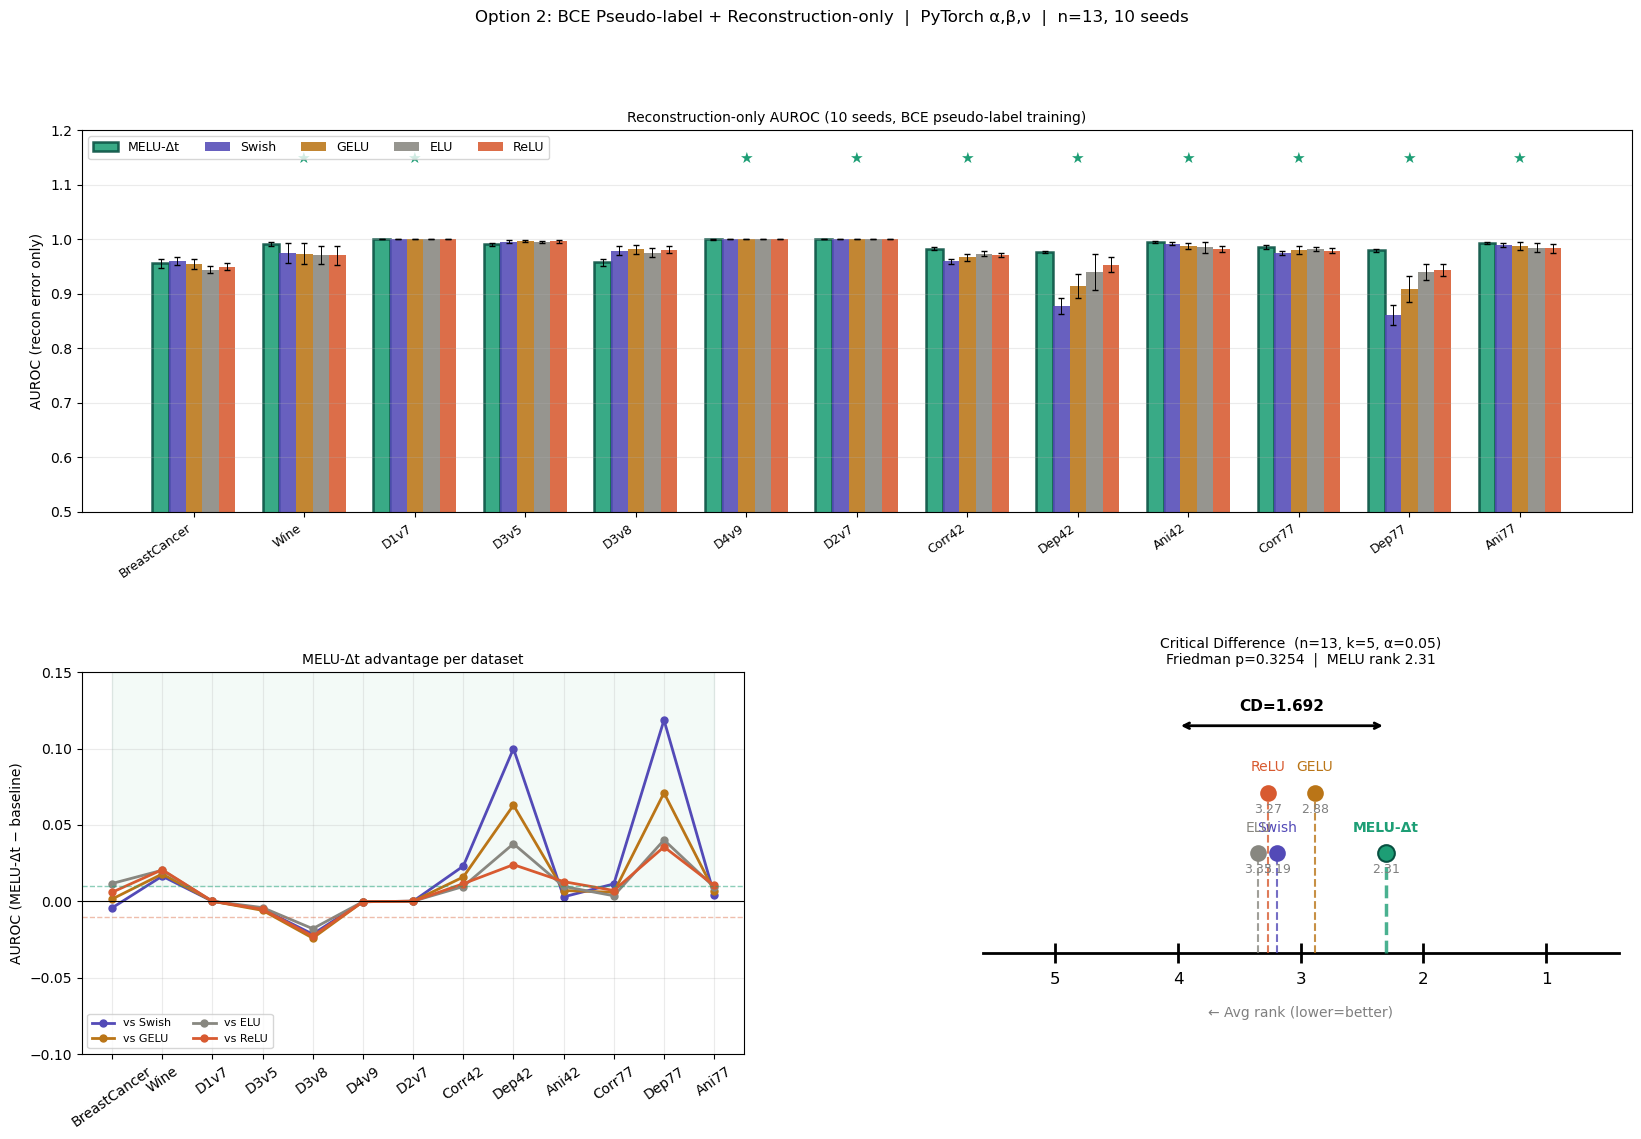

Saved → outputs/option2_final.png + option2_results.csv


In [7]:
DS=[r[0] for r in DATASETS]
A={act:np.array([np.mean(results[ds][act]) for ds in DS]) for act in ACTS}
dm=A["MELU-Δt"]; bls=[a for a in ACTS if a!="MELU-Δt"]

print("="*60); print(f"Statistical Tests  n={len(DS)} datasets"); print("="*60)
print(f"MELU-Δt mean: {dm.mean():.5f}\n")
print(f"{'Baseline':<14} {'Δ':>8} {'W':>7} {'p':>9}  sig")
print("-"*45)
W2={}
for bl in bls:
    try: Wv,p=wilcoxon(dm,A[bl],alternative="two-sided")
    except: Wv,p=0.,1.0
    sig="✓ p<0.05" if p<0.05 else "~ p<0.10" if p<0.10 else "no"
    W2[bl]=dict(p=p,delta=(dm-A[bl]).mean())
    print(f"{bl:<14} {(dm-A[bl]).mean():>+8.4f} {Wv:>7.1f} {p:>9.5f}  {sig}")

sm=np.column_stack([A[a] for a in ACTS])
fs,fp=friedmanchisquare(*sm.T)
rk=np.array([rankdata(-sm[i]) for i in range(len(DS))]).mean(0)
k=len(ACTS); nd=len(DS)
qt={5:2.728,10:3.164,12:3.268,14:3.354}; q=qt.get(k,2.728)
CD=q*np.sqrt(k*(k+1)/(6*nd))
print(f"\nFriedman χ²={fs:.3f}  p={fp:.5f}  {'SIGNIFICANT ✓' if fp<0.05 else 'not sig'}")
print(f"CD={CD:.3f}  MELU rank={rk[0]:.2f}  best={rk.min():.2f}")
wins=sum(1 for ds in DS if np.mean(results[ds]['MELU-Δt'])>=max(np.mean(results[ds][a]) for a in ACTS)-0.001)
print(f"MELU-Δt wins/ties: {wins}/{nd}")

# Figure
fig=plt.figure(figsize=(20,12))
gs=gridspec.GridSpec(2,2,figure=fig,hspace=0.42,wspace=0.34)
fig.suptitle(f"Option 2: BCE Pseudo-label + Reconstruction-only  |  "
             f"{'PyTorch α,β,ν' if TORCH else 'numpy fixed'}  |  n={nd}, 10 seeds",fontsize=12)

# AUROC bars
ax=fig.add_subplot(gs[0,:])
x=np.arange(nd); w=0.15; offs=np.linspace(-2,2,k)
for i,act in enumerate(ACTS):
    means=[np.mean(results[ds][act]) for ds in DS]
    stds =[np.std( results[ds][act]) for ds in DS]
    ax.bar(x+offs[i]*w,means,width=w,color=COLORS[act],alpha=0.88,label=act,
           linewidth=1.8 if act=="MELU-Δt" else 0.5,
           edgecolor="#085041" if act=="MELU-Δt" else "none")
    ax.errorbar(x+offs[i]*w,means,yerr=stds,fmt="none",ecolor="black",capsize=2,lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(DS,fontsize=9,rotation=35,ha='right')
ax.set_ylabel("AUROC (recon error only)"); ax.set_ylim(0.5,1.20)
ax.set_title("Reconstruction-only AUROC (10 seeds, BCE pseudo-label training)",fontsize=10)
ax.legend(fontsize=9,ncol=5); ax.grid(axis="y",alpha=0.25)
for xi,ds in enumerate(DS):
    best=max(np.mean(results[ds][a]) for a in ACTS)
    if np.mean(results[ds]["MELU-Δt"])>=best-0.001:
        ax.text(xi,1.14,"★",ha="center",fontsize=11,color="#1D9E75")

# Delta plot
ax=fig.add_subplot(gs[1,0])
for bl in bls:
    d=[np.mean(results[ds]["MELU-Δt"])-np.mean(results[ds][bl]) for ds in DS]
    ax.plot(DS,d,color=COLORS[bl],lw=2,marker="o",ms=5,label=f"vs {bl}")
ax.axhline(0,color="black",lw=0.8)
ax.axhline(0.01,color="#1D9E75",lw=1,ls="--",alpha=0.5)
ax.axhline(-0.01,color="#D85A30",lw=1,ls="--",alpha=0.4)
ax.fill_between(DS,[0.01]*nd,[0.15]*nd,alpha=0.05,color="#1D9E75")
ax.set_ylabel("AUROC (MELU-Δt − baseline)"); ax.set_ylim(-0.10,0.15)
ax.set_title("MELU-Δt advantage per dataset",fontsize=10)
ax.legend(fontsize=8,ncol=2); ax.grid(alpha=0.25); ax.tick_params(axis='x',rotation=35)

# CD diagram
ax=fig.add_subplot(gs[1,1]); ax.axis("off")
ax.set_xlim(0.3,k+0.7); ax.set_ylim(-1.5,4.2); ax.invert_xaxis()
ax.axhline(0,color="black",lw=2,xmin=0.02,xmax=0.98)
for i in range(1,k+1):
    ax.plot(i,0,"k|",ms=14,mew=2); ax.text(i,-0.45,str(i),ha="center",fontsize=12)
ax.text((k+1)/2,-0.95,"← Avg rank (lower=better)",ha="center",fontsize=10,color="gray")
sp=sorted(zip(ACTS,rk),key=lambda x:x[1])
for i,(nm,r) in enumerate(sp):
    yp=1.5 if i%2==0 else 2.4; c=COLORS[nm]; lw=2.5 if nm=="MELU-Δt" else 1.5
    ax.plot([r,r],[0,yp],color=c,lw=lw,ls="--",alpha=0.8)
    ax.plot(r,yp,"o",color=c,ms=12,zorder=5,
            markeredgecolor="#085041" if nm=="MELU-Δt" else "none",markeredgewidth=1.5)
    ax.text(r,yp+0.32,nm,ha="center",fontsize=10,
            fontweight="bold" if nm=="MELU-Δt" else "normal",color=c)
    ax.text(r,yp-0.30,f"{r:.2f}",ha="center",fontsize=9,color="gray")
br=min(rk)
ax.annotate("",xy=(br+CD,3.4),xytext=(br,3.4),
            arrowprops=dict(arrowstyle="<->",color="black",lw=2))
ax.text(br+CD/2,3.62,f"CD={CD:.3f}",ha="center",fontsize=11,fontweight="bold")
ax.set_title(f"Critical Difference  (n={nd}, k={k}, α=0.05)\n"
             f"Friedman p={fp:.4f}  |  MELU rank {rk[0]:.2f}",fontsize=10,pad=6)

plt.savefig("outputs/option2_final.png",dpi=150,bbox_inches="tight")
plt.show()

pd.DataFrame([{"dataset":ds,"activation":act,"score_mode":"recon_only","loss":"MAE+BCE",
               "auroc_mean":round(np.mean(results[ds][act]),4),
               "auroc_std": round(np.std( results[ds][act]),4)}
              for ds in DS for act in ACTS]
).to_csv("outputs/option2_results.csv",index=False)
print("Saved → outputs/option2_final.png + option2_results.csv")
